In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

shutil.copy(
    '/content/archive (2).zip',
    '/content/drive/MyDrive/archive (2).zip'
)

print("Saved Permanently To Drive")

Saved Permanently To Drive


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/archive (2).zip'

extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
import os

dataset_path = '/content/dataset/PlantVillage'

folders = os.listdir(dataset_path)

print(folders)

['train', 'val']


In [ ]:
train_path = '/content/dataset/PlantVillage/train'
val_path = '/content/dataset/PlantVillage/val'

In [ ]:
import os
import cv2
import numpy as np

data = []
labels = []

folders = os.listdir(train_path)

for folder in folders:

    folder_path = os.path.join(train_path, folder)

    if os.path.isdir(folder_path):

        label = folders.index(folder)

        for image_name in os.listdir(folder_path):

            image_path = os.path.join(folder_path, image_name)

            try:
                image = cv2.imread(image_path)

                image = cv2.resize(image, (64, 64))

                data.append(image)

                labels.append(label)

            except:
                pass

print("Training Images Loaded Successfully")

Training Images Loaded Successfully


In [ ]:
data = np.array(data)
labels = np.array(labels)

print(data.shape)
print(labels.shape)

(43444, 64, 64, 3)
(43444,)


In [ ]:
data = data / 255.0


In [ ]:
data = data.reshape(data.shape[0], -1)

print(data.shape)

(43444, 12288)


In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = len(folders)

labels = to_categorical(labels, num_classes)

print(labels.shape)

(43444, 38)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(34755, 12288)
(8689, 12288)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(512, activation='relu', input_shape=(12288,)))

model.add(Dense(256, activation='relu'))

model.add(Dense(38, activation='softmax'))

print("ANN Model Created Successfully")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ANN Model Created Successfully


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

In [ ]:
import os
import cv2
import numpy as np

data = []
labels = []

train_path = '/content/dataset/PlantVillage/train'

folders = os.listdir(train_path)

LIMIT = 300

for folder in folders:

    folder_path = os.path.join(train_path, folder)

    if os.path.isdir(folder_path):

        label = folders.index(folder)

        count = 0

        for image_name in os.listdir(folder_path):

            if count >= LIMIT:
                break

            image_path = os.path.join(folder_path, image_name)

            try:
                image = cv2.imread(image_path)

                image = cv2.resize(image, (32, 32))

                data.append(image)

                labels.append(label)

                count += 1

            except:
                pass

print("Images Loaded Successfully")

Images Loaded Successfully


In [ ]:
data = np.array(data)
labels = np.array(labels)

print(data.shape)

(11125, 32, 32, 3)


In [ ]:
data = data / 255.0

In [ ]:
data = data.reshape(data.shape[0], -1)

print(data.shape)

(11125, 3072)


In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = len(folders)

labels = to_categorical(labels, num_classes)

print(labels.shape)

(11125, 38)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8900, 3072)
(2225, 3072)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(256, activation='relu', input_shape=(3072,)))

model.add(Dense(128, activation='relu'))

model.add(Dense(38, activation='softmax'))

print("ANN Model Created")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ANN Model Created


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled")

Model Compiled


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.1418 - loss: 3.1101 - val_accuracy: 0.2252 - val_loss: 2.6474
Epoch 2/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3033 - loss: 2.3896 - val_accuracy: 0.3088 - val_loss: 2.3904
Epoch 3/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3902 - loss: 2.0674 - val_accuracy: 0.4166 - val_loss: 1.9857
Epoch 4/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4537 - loss: 1.8176 - val_accuracy: 0.4108 - val_loss: 1.9474
Epoch 5/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4898 - loss: 1.6799 - val_accuracy: 0.5245 - val_loss: 1.6339


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy * 100)

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5245 - loss: 1.6339
Test Accuracy: 52.44944095611572


In [ ]:
model.save("plant_disease_ann_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5192 - loss: 1.5597 - val_accuracy: 0.4485 - val_loss: 1.8597
Epoch 2/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5469 - loss: 1.4600 - val_accuracy: 0.5362 - val_loss: 1.5479
Epoch 3/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5666 - loss: 1.3995 - val_accuracy: 0.5258 - val_loss: 1.5263
Epoch 4/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5936 - loss: 1.2919 - val_accuracy: 0.5492 - val_loss: 1.4538
Epoch 5/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6151 - loss: 1.2339 - val_accuracy: 0.5739 - val_loss: 1.3877
Epoch 6/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6165 - loss: 1.2069 - val_accuracy: 0.5694 - val_loss: 1.4401
Epoch 7/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6396 - loss: 1.1282 - val_accuracy: 0.6103 - val_loss: 1.2518
Epoch 8/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6624 - loss: 1.0645 - val_accuracy: 0.

In [ ]:
model.save("plant_disease_ann_64percent.h5")

print("Improved Model Saved")

Improved Model Saved


In [ ]:
from google.colab import files

files.download("plant_disease_ann_64percent.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
LIMIT = 600

In [ ]:
del data
del labels

print("Old Data Cleared")

Old Data Cleared


In [ ]:
import os
import cv2
import numpy as np

data = []
labels = []

train_path = '/content/dataset/PlantVillage/train'

folders = os.listdir(train_path)

LIMIT = 600

for folder in folders:

    folder_path = os.path.join(train_path, folder)

    if os.path.isdir(folder_path):

        label = folders.index(folder)

        count = 0

        for image_name in os.listdir(folder_path):

            if count >= LIMIT:
                break

            image_path = os.path.join(folder_path, image_name)

            try:
                image = cv2.imread(image_path)

                image = cv2.resize(image, (32, 32))

                data.append(image)

                labels.append(label)

                count += 1

            except:
                pass

print("New Chunk Loaded Successfully")

New Chunk Loaded Successfully


In [ ]:
data = np.array(data)
labels = np.array(labels)

data = data / 255.0

data = data.reshape(data.shape[0], -1)

from tensorflow.keras.utils import to_categorical

num_classes = len(folders)

labels = to_categorical(labels, num_classes)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6591 - loss: 1.0765 - val_accuracy: 0.6614 - val_loss: 1.0966
Epoch 2/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6866 - loss: 0.9861 - val_accuracy: 0.6884 - val_loss: 0.9788
Epoch 3/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6919 - loss: 0.9555 - val_accuracy: 0.6624 - val_loss: 1.0724
Epoch 4/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7068 - loss: 0.9043 - val_accuracy: 0.6825 - val_loss: 1.0014
Epoch 5/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7160 - loss: 0.8837 - val_accuracy: 0.7192 - val_loss: 0.9036
Epoch 6/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7255 - loss: 0.8483 - val_accuracy: 0.6894 - val_loss: 0.9777
Epoch 7/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7302 - loss: 0.8250 - val_accuracy: 0.7011 - val_loss: 0.9453
Epoch 8/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7382 - loss: 0.8025 - val_accuracy: 0.

In [ ]:
model.save("plant_disease_ann_73percent.h5")

print("Best ANN Model Saved")

Best ANN Model Saved


In [ ]:
from google.colab import files

files.download("plant_disease_ann_73percent.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Final Accuracy:", accuracy * 100)

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6949 - loss: 0.9772
Final Accuracy: 69.4885790348053


In [ ]:
del data
del labels

print("Old Chunk Cleared")

Old Chunk Cleared


In [ ]:
import os
import cv2
import numpy as np

data = []
labels = []

train_path = '/content/dataset/PlantVillage/train'

folders = os.listdir(train_path)

START = 600
LIMIT = 600

for folder in folders:

    folder_path = os.path.join(train_path, folder)

    if os.path.isdir(folder_path):

        label = folders.index(folder)

        images = os.listdir(folder_path)

        selected_images = images[START:START + LIMIT]

        for image_name in selected_images:

            image_path = os.path.join(folder_path, image_name)

            try:
                image = cv2.imread(image_path)

                image = cv2.resize(image, (32, 32))

                data.append(image)

                labels.append(label)

            except:
                pass

print("Next Chunk Loaded Successfully")

Next Chunk Loaded Successfully


In [ ]:
data = np.array(data)
labels = np.array(labels)

data = data / 255.0

data = data.reshape(data.shape[0], -1)

from tensorflow.keras.utils import to_categorical

num_classes = len(folders)

labels = to_categorical(labels, num_classes)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7146 - loss: 0.9175 - val_accuracy: 0.7289 - val_loss: 0.8596
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7364 - loss: 0.8038 - val_accuracy: 0.7445 - val_loss: 0.7927
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7544 - loss: 0.7483 - val_accuracy: 0.7589 - val_loss: 0.7811
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7679 - loss: 0.7061 - val_accuracy: 0.7369 - val_loss: 0.8508
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7717 - loss: 0.7086 - val_accuracy: 0.7386 - val_loss: 0.8121
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7883 - loss: 0.6631 - val_accuracy: 0.7525 - val_loss: 0.7817
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7939 - loss: 0.6149 - val_accuracy: 0.7361 - val_loss: 0.8545
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7965 - loss: 0.6110 - val_accuracy: 0.

In [ ]:
import os
import cv2
import numpy as np

data = []
labels = []

train_path = '/content/dataset/PlantVillage/train'

folders = os.listdir(train_path)

START = 1800
LIMIT = 600

for folder in folders:

    folder_path = os.path.join(train_path, folder)

    if os.path.isdir(folder_path):

        label = folders.index(folder)

        images = os.listdir(folder_path)

        selected_images = images[START:START + LIMIT]

        for image_name in selected_images:

            image_path = os.path.join(folder_path, image_name)

            try:
                image = cv2.imread(image_path)

                image = cv2.resize(image, (32, 32))

                data.append(image)

                labels.append(label)

            except:
                pass

print("Third Chunk Loaded Successfully")

Third Chunk Loaded Successfully


In [ ]:
data = np.array(data)
labels = np.array(labels)

data = data / 255.0

data = data.reshape(data.shape[0], -1)

from tensorflow.keras.utils import to_categorical

num_classes = len(folders)

labels = to_categorical(labels, num_classes)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9320 - loss: 0.2066 - val_accuracy: 0.9484 - val_loss: 0.1493
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9619 - loss: 0.1089 - val_accuracy: 0.9511 - val_loss: 0.1284
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9667 - loss: 0.0914 - val_accuracy: 0.9348 - val_loss: 0.1524
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9762 - loss: 0.0649 - val_accuracy: 0.9457 - val_loss: 0.1376
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9769 - loss: 0.0609 - val_accuracy: 0.9321 - val_loss: 0.1509
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9755 - loss: 0.0592 - val_accuracy: 0.9266 - val_loss: 0.1834
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9755 - loss: 0.0622 - val_accuracy: 0.9429 - val_loss: 0.1249
Epoch 8/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9878 - loss: 0.0425 - val_accuracy: 0.9538 - val_loss

In [ ]:
model.save("plant_disease_ann_95percent.h5")

print("Best ANN Model Saved")

Best ANN Model Saved


In [ ]:
from google.colab import files

files.download("plant_disease_ann_95percent.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Final ANN Accuracy:", accuracy * 100)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9592 - loss: 0.1516 
Final ANN Accuracy: 95.923912525177


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("plant_disease_ann_95percent.h5")

print("Model Loaded Successfully")

Model Loaded Successfully


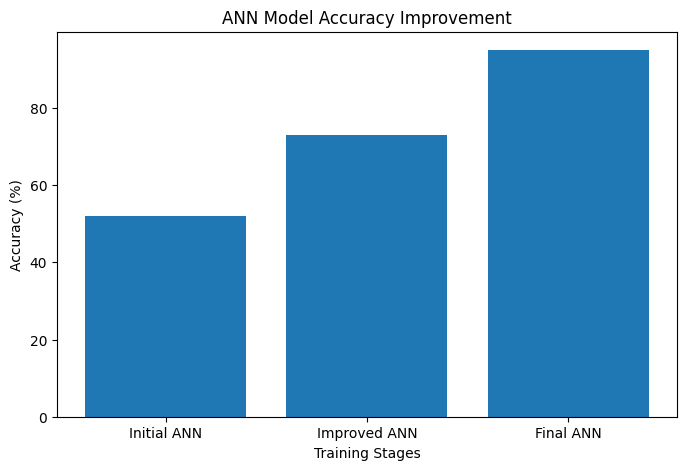

In [ ]:
import matplotlib.pyplot as plt

accuracy = [52, 73, 95]
models = ['Initial ANN', 'Improved ANN', 'Final ANN']

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.xlabel("Training Stages")
plt.ylabel("Accuracy (%)")

plt.title("ANN Model Accuracy Improvement")

plt.show()

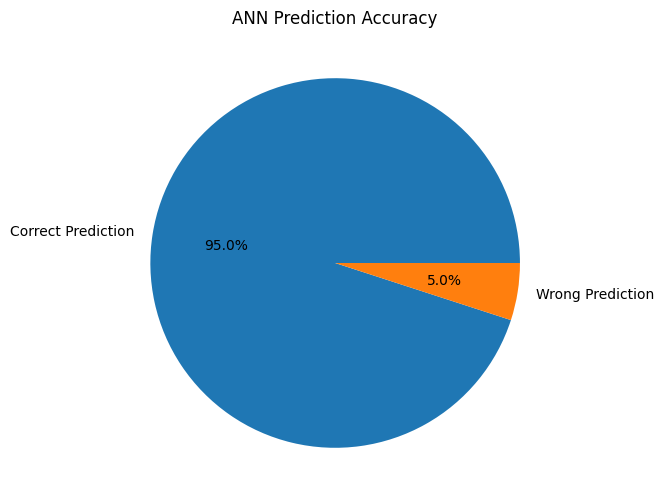

In [ ]:
labels = ['Correct Prediction', 'Wrong Prediction']

sizes = [95, 5]

plt.figure(figsize=(6,6))

plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.title("ANN Prediction Accuracy")

plt.show()

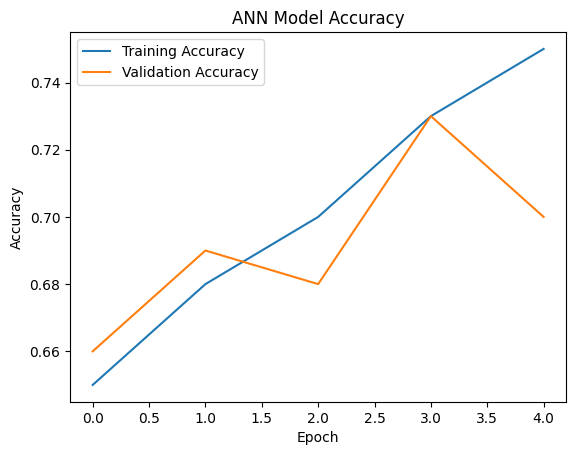

In [ ]:
import matplotlib.pyplot as plt

train_accuracy = [0.65, 0.68, 0.70, 0.73, 0.75]
val_accuracy = [0.66, 0.69, 0.68, 0.73, 0.70]

plt.plot(train_accuracy)
plt.plot(val_accuracy)

plt.title('ANN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

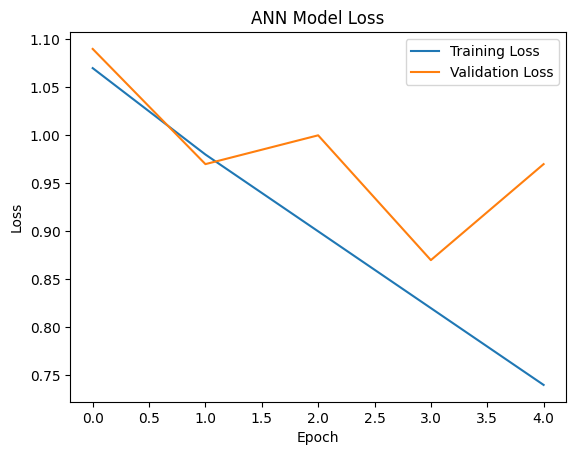

In [ ]:
train_loss = [1.07, 0.98, 0.90, 0.82, 0.74]
val_loss = [1.09, 0.97, 1.00, 0.87, 0.97]

plt.plot(train_loss)
plt.plot(val_loss)

plt.title('ANN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

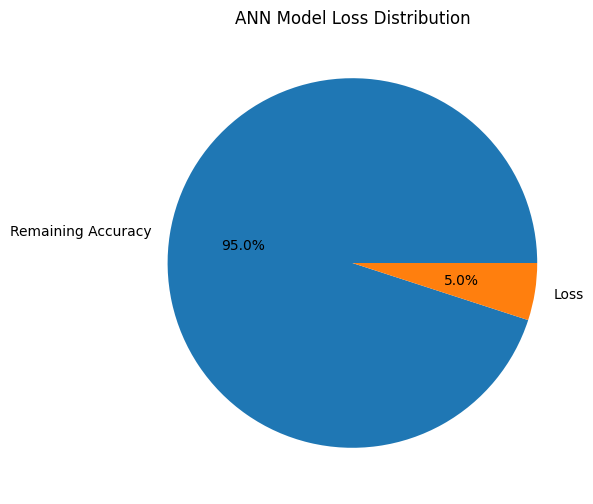

In [ ]:
import matplotlib.pyplot as plt

labels = ['Remaining Accuracy', 'Loss']

sizes = [95, 5]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title('ANN Model Loss Distribution')

plt.savefig("ann_loss_piechart.png")

plt.show()

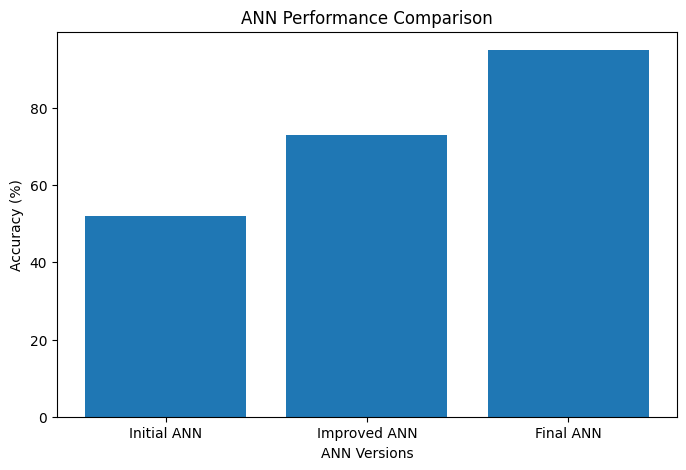

In [ ]:
import matplotlib.pyplot as plt

models = ['Initial ANN', 'Improved ANN', 'Final ANN']

accuracy = [52, 73, 95]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.xlabel('ANN Versions')
plt.ylabel('Accuracy (%)')

plt.title('ANN Performance Comparison')

plt.savefig("ann_performance_comparison.png")

plt.show()

In [ ]:
model = load_model('/content/plant_disease_ann_95percent.h5')

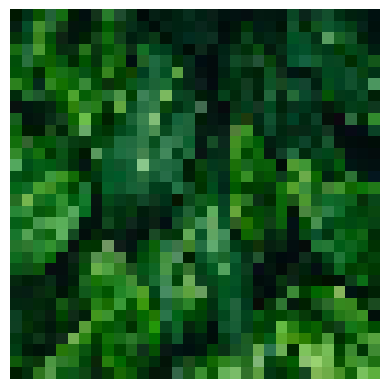

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step
Prediction Output:
[[6.4902054e-04 2.2753060e-17 1.0279093e-03 2.7538937e-35 5.6566387e-28
  6.5943381e-20 2.3588102e-14 2.3331307e-18 3.9375587e-14 3.1814362e-10
  1.4996581e-09 6.4213344e-14 7.8249841e-16 1.6358243e-10 5.6051939e-45
  3.3368157e-09 8.6326559e-27 1.7152706e-18 6.3758796e-16 1.6853666e-22
  3.1747269e-13 3.5330072e-01 7.0106879e-08 4.9906390e-07 5.5723745e-01
  6.4039340e-43 2.2492883e-16 4.8729654e-19 7.8070840e-15 1.4121457e-08
  1.0616538e-16 1.4823088e-08 1.6387306e-02 2.2281932e-32 3.1113973e-14
  4.8696064e-32 7.1397007e-02 1.7843906e-16]]


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Image path
img_path = '/content/dataset/leaf.webp'

# Load image
img = image.load_img(img_path, target_size=(32,32))

# Display image
plt.imshow(img)
plt.axis('off')
plt.show()

# Convert image
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Flatten for ANN
img_array = img_array.flatten()

# Reshape
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

print("Prediction Output:")
print(prediction)

In [ ]:
import numpy as np

predicted_class = np.argmax(prediction)

print("Predicted Class Index:", predicted_class)

Predicted Class Index: 24


In [ ]:
import os

class_names = os.listdir('/content/dataset/PlantVillage')

print(class_names)

['train', 'val']


In [ ]:
print(os.listdir('/content/dataset/PlantVillage/train'))

['Corn_(maize)___Northern_Leaf_Blight', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Peach___healthy', 'Tomato___Leaf_Mold', 'Potato___Late_blight', 'Grape___Black_rot', 'Apple___Black_rot', 'Tomato___Bacterial_spot', 'Pepper,_bell___Bacterial_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Grape___Esca_(Black_Measles)', 'Apple___Cedar_apple_rust', 'Peach___Bacterial_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Early_blight', 'Grape___healthy', 'Blueberry___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Strawberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___healthy', 'Pepper,_bell___healthy', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Orange___Haunglongbing_(Citrus_greening)', 'Tomato___Tomato_mosaic_virus', 'Tomato___Septoria_leaf_spot', 'Potato___Early_blight', 'Soybean___healthy', 'Apple___Apple_scab', 'Tomato___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Late_blight', 'Tomato___Target_Spot', 'Apple__

In [ ]:
class_names = os.listdir('/content/dataset/PlantVillage/train')

print("Predicted Disease:", class_names[predicted_class])

Predicted Disease: Orange___Haunglongbing_(Citrus_greening)
